In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [7]:
import warnings
warnings.filterwarnings("ignore")

In [8]:
df = pd.read_csv(r"C:\Users\ZAKKI BOSS TRADERS\Desktop\Practice\train-test.csv")
df

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47995,TR-047996,Reno,Baton Rouge,39.54838,-118.64843,30.50134,-92.65374,1830.9,Flatbed,31786.0,2025-10-31,0.98865,2.05626,3787.32
47996,TR-047997,Greensboro,Memphis,35.98195,-82.78379,35.56802,-89.52871,445.8,Reefer,37465.0,2025-10-31,1.03034,1.51985,1171.93
47997,TR-047998,Greensboro,Cincinnati,35.98195,-82.78379,37.15706,-86.77499,267.9,Flatbed,24528.0,2025-10-31,1.00846,1.46954,713.36
47998,TR-047999,Memphis,Reno,35.56802,-89.52871,39.54838,-118.64843,1901.3,Flatbed,37581.0,2025-10-31,1.00014,2.05132,3987.46


In [9]:
df.shape

(48000, 14)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  str    
 1   pickup        48000 non-null  str    
 2   delivery      48000 non-null  str    
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  str    
 9   weight        47700 non-null  float64
 10  date          48000 non-null  str    
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), str(5)
memory usage: 7.1 MB


In [11]:
df.isnull().sum()

load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
dtype: int64

In [12]:
missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df) * 100).round(2)})
missing_summary

,Missing_Count,Missing_Percentage
load_id,0,0.00
pickup,0,0.00
delivery,0,0.00
pickup_lat,0,0.00
pickup_lon,0,0.00
delivery_lat,0,0.00
delivery_lon,0,0.00
distance,0,0.00
equipment,0,0.00
weight,300,0.62


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df["load_id"].nunique(), len(df)

(48000, 48000)

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
pickup_lat,48000.0,35.647545,4.315285,28.35765,31.98691,35.29479,39.411040,44.30296
pickup_lon,48000.0,-90.928964,13.482431,-121.69849,-98.40059,-88.08915,-83.285060,-69.50000
delivery_lat,48000.0,35.641175,4.317199,28.35765,31.98691,35.29479,39.411040,44.30296
delivery_lon,48000.0,-90.857310,13.476589,-121.69849,-98.40059,-87.52871,-83.285060,-69.50000
distance,48000.0,1135.856654,728.564416,70.00000,550.40000,953.30000,1645.525000,3439.80000
weight,47700.0,31028.844004,9391.440620,-47500.00000,25800.00000,31436.50000,37018.000000,47500.00000
market_index,47626.0,1.083387,0.168091,0.67639,0.94967,1.05580,1.219590,1.46778
quote_signal,48000.0,2.062468,0.291391,0.69228,1.89103,2.05575,2.221685,3.61035
posted_rate,48000.0,2373.980682,1486.493245,57.22000,1251.55500,2030.76000,3330.750000,25533.00000


In [16]:
(df["weight"] < 0).sum()

np.int64(292)

In [17]:
df[df["weight"] < 0].head(10)

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
68,TR-000069,Amarillo,Dayton,33.17137,-104.36789,39.87206,-85.62931,1334.2,Reefer,-36559.0,2025-01-01,0.96102,2.11777,2831.27
204,TR-000205,Fresno,Tucson,33.07921,-119.79528,30.92733,-113.23037,496.2,Dry Van,-26670.0,2025-01-02,0.96903,2.13155,1046.92
206,TR-000207,Columbia,Raleigh,34.63570,-83.28506,35.37376,-77.47605,411.3,Reefer,-20003.0,2025-01-02,0.94800,2.31682,959.15
225,TR-000226,Greensboro,Lubbock,35.98195,-82.78379,29.87534,-99.85456,1317.4,Reefer,-23981.0,2025-01-02,1.00820,2.13918,2836.00
376,TR-000377,Madison,Providence,41.70243,-89.85588,37.37287,-69.50000,1331.1,Dry Van,-41397.0,2025-01-03,0.94787,1.91867,2522.54
446,TR-000447,Albuquerque,Albany,35.39918,-109.59792,43.96975,-71.05842,2438.3,Reefer,-37215.0,2025-01-03,0.96575,1.96959,4841.57
495,TR-000496,Montgomery,Dayton,31.37602,-86.10743,39.87206,-85.62931,715.9,Dry Van,-31214.0,2025-01-04,0.85153,2.03947,1473.78
641,TR-000642,Tulsa,Indianapolis,33.45894,-94.78556,38.52567,-88.85948,582.4,Dry Van,-41023.0,2025-01-05,0.81988,2.22721,1264.33
806,TR-000807,Cincinnati,Buffalo,37.15706,-86.77499,41.67681,-78.56704,676.1,Dry Van,-28320.0,2025-01-06,0.79158,1.95680,1307.76
1093,TR-001094,Cincinnati,Albany,37.15706,-86.77499,43.96975,-71.05842,1058.5,Dry Van,-25153.0,2025-01-07,0.89891,1.81081,1907.83


In [18]:
df[df["weight"] < 0]["weight"].describe()

count      292.000000
mean    -31724.195205
std       8262.536326
min     -47500.000000
25%     -37284.250000
50%     -31821.500000
75%     -25928.500000
max      -5000.000000
Name: weight, dtype: float64

In [19]:
positive_weights = df.loc[df["weight"] > 0, "weight"]
negative_weights = df.loc[df["weight"] < 0, "weight"].abs()

print("Positive Weight:")
print(positive_weights.describe())

print("\nNegative Weight (Absolute Values):")
print(negative_weights.describe())

Positive Weight:
count    47408.000000
mean     31415.358674
std       7994.902979
min       5000.000000
25%      25922.000000
50%      31493.500000
75%      37063.000000
max      47500.000000
Name: weight, dtype: float64

Negative Weight (Absolute Values):
count      292.000000
mean     31724.195205
std       8262.536326
min       5000.000000
25%      25928.500000
50%      31821.500000
75%      37284.250000
max      47500.000000
Name: weight, dtype: float64


In [20]:
print("Zero weights:", (df["weight"] == 0).sum())
print("Negative weights:", (df["weight"] < 0).sum())
print("Missing weights:", df["weight"].isnull().sum())

Zero weights: 0
Negative weights: 292
Missing weights: 300


In [21]:
df["weight"] = df["weight"].abs()

In [22]:
print("Negative weights:", (df["weight"] < 0).sum())
print("Missing weights:", df["weight"].isnull().sum())

Negative weights: 0
Missing weights: 300


In [23]:
categorical_columns = ["pickup", "delivery", "equipment"]
for col in categorical_columns:
    print(f"\n{col}")
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts().head(10))


pickup
Unique values: 64
pickup
Oklahoma City    1242
Lexington        1209
Bakersfield      1193
Fort Wayne       1170
Hartford         1150
Richmond         1140
Nashville        1124
Phoenix          1121
Baton Rouge      1115
Mobile           1094
Name: count, dtype: int64

delivery
Unique values: 64
delivery
Lexington        1197
Fort Wayne       1176
Baton Rouge      1167
Bakersfield      1156
Hartford         1143
Oklahoma City    1140
Richmond         1109
Atlanta          1096
Phoenix          1090
Mobile           1089
Name: count, dtype: int64

equipment
Unique values: 3
equipment
Dry Van    27202
Reefer     12045
Flatbed     8753
Name: count, dtype: int64


In [24]:
print("Minimum Date:", df["date"].min())
print("Maximum Date:", df["date"].max())
print("Unique Dates:", df["date"].nunique())

Minimum Date: 2025-01-01
Maximum Date: 2025-10-31
Unique Dates: 304


In [25]:
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek

In [26]:
df[["date", "month", "day", "day_of_week"]].head()

,date,month,day,day_of_week
0,2025-01-01,1,1,2
1,2025-01-01,1,1,2
2,2025-01-01,1,1,2
3,2025-01-01,1,1,2
4,2025-01-01,1,1,2


In [27]:
df.groupby(df["date"].dt.month)["posted_rate"].agg(
    ["count", "mean", "median"]
).round(2)

,count,mean,median
date,,,
1,4918,2255.97,1915.20
2,4337,2273.80,1994.25
3,5036,2372.27,2022.92
4,4819,2372.16,2044.24
5,4913,2421.78,2065.51
6,4783,2497.03,2120.22
7,4912,2415.16,2059.14
8,4759,2338.41,2015.73
9,4670,2406.37,2057.13


In [28]:
df["month"].value_counts().sort_index()

month
1     4918
2     4337
3     5036
4     4819
5     4913
6     4783
7     4912
8     4759
9     4670
10    4853
Name: count, dtype: int64

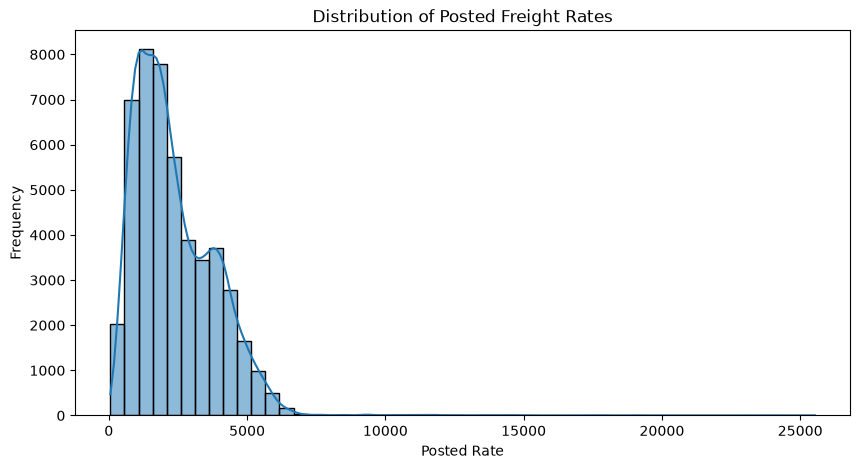

In [29]:
plt.figure(figsize=(10, 5))
sns.histplot(df["posted_rate"], bins=50, kde=True)
plt.title("Distribution of Posted Freight Rates")
plt.xlabel("Posted Rate")
plt.ylabel("Frequency")
plt.show()

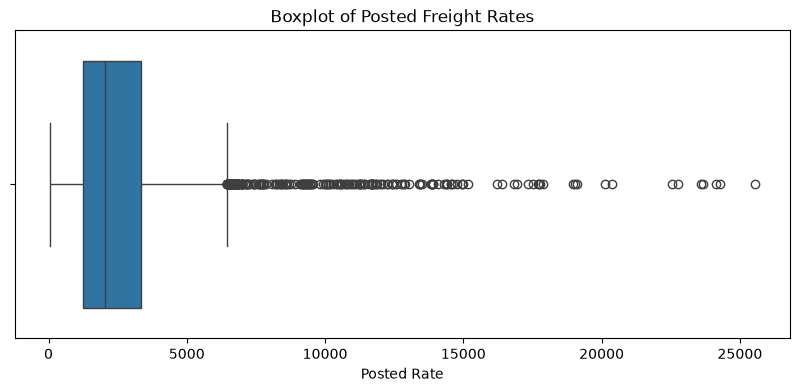

In [30]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df["posted_rate"])
plt.title("Boxplot of Posted Freight Rates")
plt.xlabel("Posted Rate")
plt.show()

In [31]:
Q1 = df["posted_rate"].quantile(0.25)
Q3 = df["posted_rate"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[
    (df["posted_rate"] < lower_bound) |
    (df["posted_rate"] > upper_bound)]
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", len(outliers))
print("Outlier Percentage:", round(len(outliers) / len(df) * 100, 2), "%")

Q1: 1251.5549999999998
Q3: 3330.75
IQR: 2079.195
Lower Bound: -1867.2375000000006
Upper Bound: 6449.5425000000005
Number of Outliers: 260
Outlier Percentage: 0.54 %


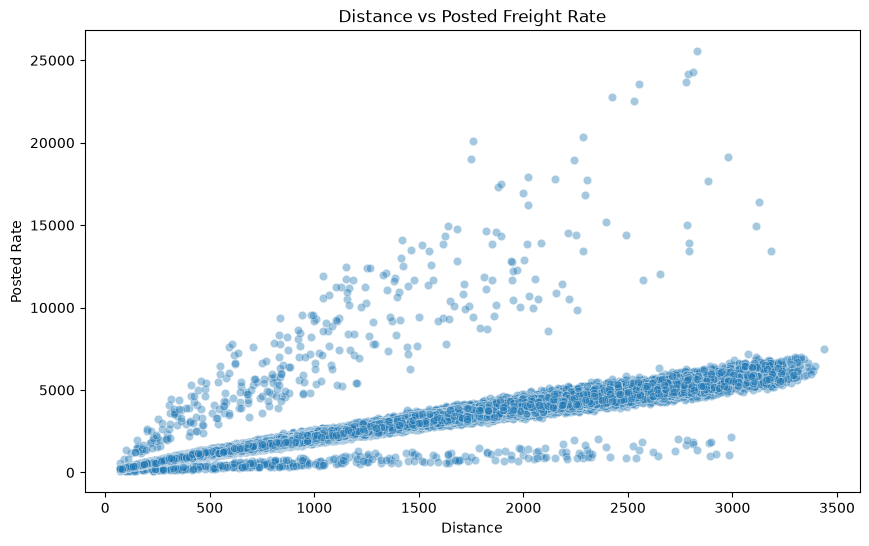

In [32]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="distance",
    y="posted_rate",
    alpha=0.4)
plt.title("Distance vs Posted Freight Rate")
plt.xlabel("Distance")
plt.ylabel("Posted Rate")
plt.show()

In [33]:
correlation = df["distance"].corr(df["posted_rate"])
print("Correlation between Distance and Posted Rate:", round(correlation, 3))

Correlation between Distance and Posted Rate: 0.909


In [34]:
outliers[
    ["distance", "equipment", "weight",
     "market_index", "quote_signal", "posted_rate"]
].sort_values("posted_rate", ascending=False).head(10)

,distance,equipment,weight,market_index,quote_signal,posted_rate
12184,2829.8,Dry Van,33153.0,1.16556,1.83188,25533.00
37764,2810.9,Dry Van,33674.0,1.04877,2.16284,24294.98
1466,2786.0,Reefer,30322.0,0.98678,1.85370,24140.21
17371,2777.6,Reefer,33158.0,1.15070,2.15601,23662.71
26235,2552.5,Dry Van,25665.0,1.20224,1.81289,23580.42
28219,2423.3,Dry Van,30972.0,1.32894,1.97112,22755.66
3353,2527.9,Reefer,36840.0,1.03241,2.07342,22534.65
40171,2283.4,Dry Van,32447.0,0.98502,1.93645,20361.89
40096,1760.3,Reefer,29521.0,1.00464,2.28753,20132.37
47298,2979.1,Reefer,30585.0,0.86501,2.09472,19110.30


In [35]:
equipment_summary = df.groupby("equipment")["posted_rate"].agg(
    ["count", "mean", "median"]).round(2)
equipment_summary

,count,mean,median
equipment,,,
Dry Van,27202,2271.55,1953.04
Flatbed,8753,2445.09,2076.81
Reefer,12045,2553.64,2196.67


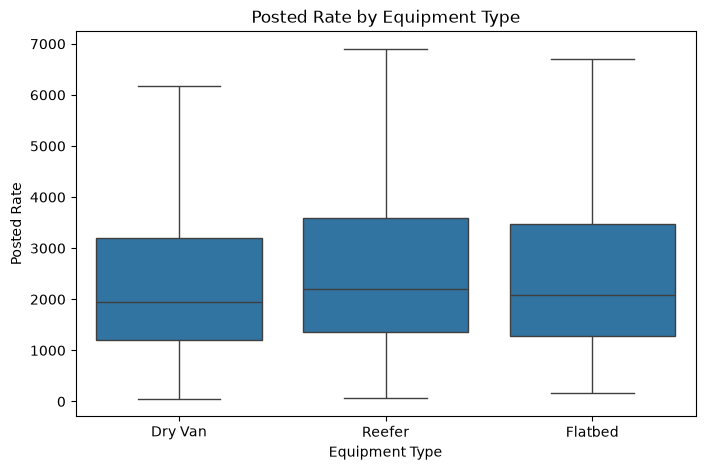

In [36]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="equipment",
    y="posted_rate",
    showfliers=False)
plt.title("Posted Rate by Equipment Type")
plt.xlabel("Equipment Type")
plt.ylabel("Posted Rate")
plt.show()

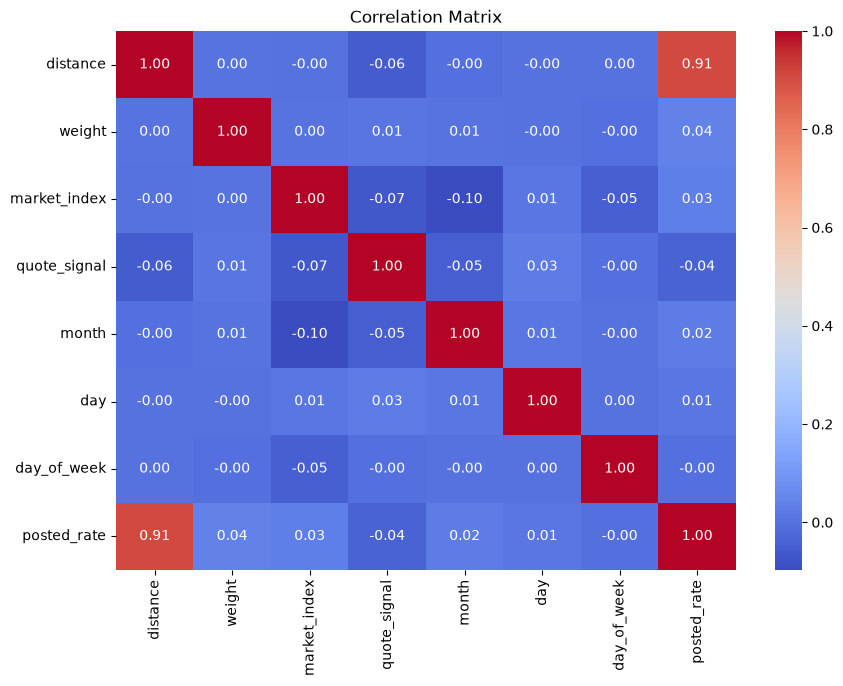

In [37]:
numeric_cols = ["distance","weight", "market_index", "quote_signal","month","day", "day_of_week","posted_rate"]
correlation_matrix = df[numeric_cols].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [38]:
X = df.drop(columns=["posted_rate", "load_id", "date"])
y = df["posted_rate"]

In [39]:
print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (48000, 14)
y shape: (48000,)


,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,market_index,quote_signal,month,day,day_of_week
0,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,0.95684,2.39595,1,1,2
1,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,0.97623,2.43355,1,1,2
2,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,1.00971,1.84491,1,1,2
3,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,0.94518,1.87712,1,1,2
4,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,0.98480,2.56300,1,1,2


In [40]:
train_mask = df["date"] < "2025-10-01"
valid_mask = df["date"] >= "2025-10-01"
X_train = X.loc[train_mask]
X_valid = X.loc[valid_mask]
y_train = y.loc[train_mask]
y_valid = y.loc[valid_mask]
print("Training shape:", X_train.shape)
print("Validation shape:", X_valid.shape)
print("\nTraining period:")
print(df.loc[train_mask, "date"].min(), "to", df.loc[train_mask, "date"].max())
print("\nValidation period:")
print(df.loc[valid_mask, "date"].min(), "to", df.loc[valid_mask, "date"].max())

Training shape: (43147, 14)
Validation shape: (4853, 14)

Training period:
2025-01-01 00:00:00 to 2025-09-30 00:00:00

Validation period:
2025-10-01 00:00:00 to 2025-10-31 00:00:00


In [41]:
categorical_features = ["pickup","delivery",  "equipment"]
numerical_features = ["pickup_lat","pickup_lon",  "delivery_lat", "delivery_lon", "distance","weight","market_index", "quote_signal",  "month", "day","day_of_week"]
print("Categorical Features:", len(categorical_features))
print("Numerical Features:", len(numerical_features))

Categorical Features: 3
Numerical Features: 11


In [42]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))])
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)])
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [43]:
SimpleImputer(strategy="median")

,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [44]:
handle_unknown="ignore"

In [45]:
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['pickup','delivery','pickup_lat',...,'month','day','day_of_week']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis co

In [46]:
y_pred_linear = linear_model.predict(X_valid)
mae = mean_absolute_error(y_valid, y_pred_linear)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred_linear))
r2 = r2_score(y_valid, y_pred_linear)
print("Linear Regression")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))

Linear Regression
MAE : 138.92
RMSE: 651.62
R²  : 0.8183


In [47]:
random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=50,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ))
])

random_forest_model.fit(X_train, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [48]:
y_pred_rf = random_forest_model.predict(X_valid)

rf_mae = mean_absolute_error(y_valid, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_valid, y_pred_rf))
rf_r2 = r2_score(y_valid, y_pred_rf)

print("Random Forest")
print("MAE :", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R²  :", round(rf_r2, 4))

Random Forest
MAE : 164.59
RMSE: 700.47
R²  : 0.79


In [49]:
gradient_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gradient_model.fit(X_train, y_train)

print("Gradient Boosting training completed!")

Gradient Boosting training completed!


In [50]:
y_pred_gb = gradient_model.predict(X_valid)

gb_mae = mean_absolute_error(y_valid, y_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_valid, y_pred_gb))
gb_r2 = r2_score(y_valid, y_pred_gb)

print("Gradient Boosting")
print("MAE :", round(gb_mae, 2))
print("RMSE:", round(gb_rmse, 2))
print("R²  :", round(gb_r2, 4))


Gradient Boosting
MAE : 131.7
RMSE: 651.92
R²  : 0.8181


In [51]:
gradient_model_2 = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        min_samples_leaf=5,
        random_state=42
    ))
])

gradient_model_2.fit(X_train, y_train)

print("Tuned Gradient Boosting training completed!")

Tuned Gradient Boosting training completed!


In [52]:
y_pred_gb2 = gradient_model_2.predict(X_valid)

gb2_mae = mean_absolute_error(y_valid, y_pred_gb2)
gb2_rmse = np.sqrt(mean_squared_error(y_valid, y_pred_gb2))
gb2_r2 = r2_score(y_valid, y_pred_gb2)

print("Tuned Gradient Boosting")
print("MAE :", round(gb2_mae, 2))
print("RMSE:", round(gb2_rmse, 2))
print("R²  :", round(gb2_r2, 4))

Tuned Gradient Boosting
MAE : 118.26
RMSE: 648.65
R²  : 0.8199


In [53]:
df["route"] = df["pickup"] + " → " + df["delivery"]

df[["pickup", "delivery", "route"]].head()

,pickup,delivery,route
0,Richmond,Baltimore,Richmond → Baltimore
1,Richmond,Philadelphia,Richmond → Philadelphia
2,Philadelphia,Green Bay,Philadelphia → Green Bay
3,Hartford,Atlanta,Hartford → Atlanta
4,Dallas,Nashville,Dallas → Nashville


In [54]:
y = df["posted_rate"]

X = df.drop(columns=[
    "posted_rate",
    "load_id",
    "date"
])

print("X shape:", X.shape)
print("Features:")
print(X.columns.tolist())

X shape: (48000, 15)
Features:
['pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'market_index', 'quote_signal', 'month', 'day', 'day_of_week', 'route']


In [55]:
categorical_features = ["pickup", "delivery","equipment", "route"]
numerical_features = ["pickup_lat", "pickup_lon", "delivery_lat","delivery_lon", "distance",  "weight","market_index","quote_signal",
    "month",
    "day",
    "day_of_week"]
print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numerical_features))

Categorical features: 4
Numerical features: 11


In [56]:
train_mask = df["date"] < "2025-10-01"
valid_mask = df["date"] >= "2025-10-01"

X_train = X.loc[train_mask]
X_valid = X.loc[valid_mask]

y_train = y.loc[train_mask]
y_valid = y.loc[valid_mask]

print("Training shape:", X_train.shape)
print("Validation shape:", X_valid.shape)

Training shape: (43147, 15)
Validation shape: (4853, 15)


In [57]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))])
preprocessor_route = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)])
print("Route preprocessing pipeline ready!")

Route preprocessing pipeline ready!


In [59]:
gradient_route_model = Pipeline(steps=[
    ("preprocessor", preprocessor_route),
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        min_samples_leaf=5,
        random_state=42
    ))
])

gradient_route_model.fit(X_train, y_train)

print("Route Gradient Boosting training completed!")

Route Gradient Boosting training completed!


In [60]:
y_pred_route = gradient_route_model.predict(X_valid)

route_mae = mean_absolute_error(y_valid, y_pred_route)
route_rmse = np.sqrt(mean_squared_error(y_valid, y_pred_route))
route_r2 = r2_score(y_valid, y_pred_route)

print("Gradient Boosting + Route")
print("MAE :", round(route_mae, 2))
print("RMSE:", round(route_rmse, 2))
print("R²  :", round(route_r2, 4))

Gradient Boosting + Route
MAE : 124.35
RMSE: 653.9
R²  : 0.817


In [62]:
validation_df = pd.read_csv(r"C:\Users\ZAKKI BOSS TRADERS\Desktop\Practice\validation.csv")

print("Shape:", validation_df.shape)
print("\nColumns:")
print(validation_df.columns.tolist())

print("\nData types:")
print(validation_df.dtypes)

print("\nMissing values:")
print(validation_df.isnull().sum())

validation_df.head()

Shape: (12000, 13)

Columns:
['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal']

Data types:
load_id             str
pickup              str
delivery            str
pickup_lat      float64
pickup_lon      float64
delivery_lat    float64
delivery_lon    float64
distance        float64
equipment           str
weight          float64
date                str
market_index    float64
quote_signal    float64
dtype: object

Missing values:
load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          165
date              0
market_index    249
quote_signal      0
dtype: int64


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal
0,TE-000001,Baton Rouge,Mobile,30.50134,-92.65374,31.80442,-88.25195,331.4,Flatbed,19958.0,2025-11-01,0.90402,1.86388
1,TE-000002,Savannah,Los Angeles,33.60973,-82.29994,28.56624,-116.70249,2406.2,Reefer,34114.0,2025-11-01,0.92851,1.86240
2,TE-000003,San Francisco,Raleigh,35.19670,-121.69849,35.37376,-77.47605,2846.6,Dry Van,33435.0,2025-11-01,0.88117,1.95480
3,TE-000004,Dayton,Los Angeles,39.87206,-85.62931,28.56624,-116.70249,2261.6,Dry Van,25392.0,2025-11-01,0.89156,2.14579
4,TE-000005,Memphis,San Antonio,35.56802,-89.52871,29.50969,-98.40059,800.4,Flatbed,NaN,2025-11-01,0.88308,2.22541


In [63]:
validation_df["date"] = pd.to_datetime(validation_df["date"])
validation_df["month"] = validation_df["date"].dt.month
validation_df["day"] = validation_df["date"].dt.day
validation_df["day_of_week"] = validation_df["date"].dt.dayofweek
validation_df["weight"] = validation_df["weight"].abs()
print("Negative weights:", (validation_df["weight"] < 0).sum())
print("Shape:", validation_df.shape)
validation_df[["date", "month", "day", "day_of_week"]].head()

Negative weights: 0
Shape: (12000, 16)


,date,month,day,day_of_week
0,2025-11-01,11,1,5
1,2025-11-01,11,1,5
2,2025-11-01,11,1,5
3,2025-11-01,11,1,5
4,2025-11-01,11,1,5


In [64]:
print(gradient_model_2.named_steps["preprocessor"].feature_names_in_)

['pickup' 'delivery' 'pickup_lat' 'pickup_lon' 'delivery_lat'
 'delivery_lon' 'distance' 'equipment' 'weight' 'market_index'
 'quote_signal' 'month' 'day' 'day_of_week']


In [65]:
model_features = [
    "pickup",
    "delivery",
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "distance",
    "equipment",
    "weight",
    "market_index",
    "quote_signal",
    "month",
    "day",
    "day_of_week"]
X_test = validation_df[model_features]
validation_predictions = gradient_model_2.predict(X_test)
print("Number of predictions:", len(validation_predictions))
print("First 5 predictions:")
print(validation_predictions[:5])

Number of predictions: 12000
First 5 predictions:
[ 851.78494204 4962.76145388 5417.14789599 4033.84392167 1832.47091533]


In [66]:
print("NaN predictions:", np.isnan(validation_predictions).sum())
print("Infinite predictions:", np.isinf(validation_predictions).sum())
print("Zero/negative predictions:", (validation_predictions <= 0).sum())
print("\nMinimum prediction:", round(validation_predictions.min(), 2))
print("Maximum prediction:", round(validation_predictions.max(), 2))
print("Average prediction:", round(validation_predictions.mean(), 2))

NaN predictions: 0
Infinite predictions: 0
Zero/negative predictions: 0

Minimum prediction: 227.92
Maximum prediction: 6924.85
Average prediction: 2379.62


In [67]:
final_predictions = pd.DataFrame({
    "load_id": validation_df["load_id"],
    "predicted_rate": validation_predictions})
final_predictions.to_csv(
    "validation_predictions.csv",
    index=False)
print("File saved successfully!")
print("Shape:", final_predictions.shape)
print("Columns:", final_predictions.columns.tolist())

final_predictions.head()

File saved successfully!
Shape: (12000, 2)
Columns: ['load_id', 'predicted_rate']


,load_id,predicted_rate
0,TE-000001,851.784942
1,TE-000002,4962.761454
2,TE-000003,5417.147896
3,TE-000004,4033.843922
4,TE-000005,1832.470915


In [69]:
december_df = pd.read_csv(r"C:\Users\ZAKKI BOSS TRADERS\Desktop\Practice\december-chart-inputs.csv")
print("Shape:", december_df.shape)
print("\nColumns:")
print(december_df.columns.tolist())
print("\nData types:")
print(december_df.dtypes)
print("\nMissing values:")
print(december_df.isnull().sum())
december_df.head()

Shape: (31, 7)

Columns:
['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']

Data types:
pickup                str
delivery              str
distance            int64
equipment             str
weight              int64
date                  str
predicted_rate    float64
dtype: object

Missing values:
pickup             0
delivery           0
distance           0
equipment          0
weight             0
date               0
predicted_rate    31
dtype: int64


,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,NaN
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,NaN
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,NaN
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,NaN
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,NaN


In [70]:
lane_data = df[(df["pickup"] == "Lexington") &  (df["delivery"] == "Fort Wayne")]
print("Lexington → Fort Wayne rows:", len(lane_data))
lane_data[["pickup_lat","pickup_lon","delivery_lat", "delivery_lon", "market_index", "quote_signal","posted_rate"]].describe()

Lexington → Fort Wayne rows: 32


,pickup_lat,pickup_lon,delivery_lat,delivery_lon,market_index,quote_signal,posted_rate
count,32.00000,32.00000,32.00000,32.00000,32.000000,32.000000,32.000000
mean,36.99152,-84.99876,41.31561,-85.36206,1.041472,2.010673,856.589062
std,0.00000,0.00000,0.00000,0.00000,0.174214,0.325412,63.194715
min,36.99152,-84.99876,41.31561,-85.36206,0.795540,1.553620,757.930000
25%,36.99152,-84.99876,41.31561,-85.36206,0.896825,1.752600,796.652500
50%,36.99152,-84.99876,41.31561,-85.36206,1.044020,1.972520,848.610000
75%,36.99152,-84.99876,41.31561,-85.36206,1.154707,2.249500,912.590000
max,36.99152,-84.99876,41.31561,-85.36206,1.406170,2.706310,973.750000


In [71]:
december_df["date"] = pd.to_datetime(december_df["date"])
december_df["month"] = december_df["date"].dt.month
december_df["day"] = december_df["date"].dt.day
december_df["day_of_week"] = december_df["date"].dt.dayofweek
december_df["pickup_lat"] = 36.99152
december_df["pickup_lon"] = -84.99876
december_df["delivery_lat"] = 41.31561
december_df["delivery_lon"] = -85.36206
december_df["market_index"] = 1.044020
december_df["quote_signal"] = 1.972520
december_df[["date","month","day","day_of_week",  "market_index", "quote_signal"]].head()

,date,month,day,day_of_week,market_index,quote_signal
0,2025-12-01,12,1,0,1.04402,1.97252
1,2025-12-02,12,2,1,1.04402,1.97252
2,2025-12-03,12,3,2,1.04402,1.97252
3,2025-12-04,12,4,3,1.04402,1.97252
4,2025-12-05,12,5,4,1.04402,1.97252


In [72]:
X_december = december_df[model_features]

december_predictions = gradient_model_2.predict(X_december)

december_df["predicted_rate"] = december_predictions

print("Number of predictions:", len(december_predictions))
print("Minimum rate:", round(december_predictions.min(), 2))
print("Maximum rate:", round(december_predictions.max(), 2))
print("Average rate:", round(december_predictions.mean(), 2))

december_df[["date", "predicted_rate"]]

Number of predictions: 31
Minimum rate: 1029.87
Maximum rate: 1047.82
Average rate: 1039.93


,date,predicted_rate
0,2025-12-01,1030.911774
1,2025-12-02,1030.911774
2,2025-12-03,1030.911774
3,2025-12-04,1030.911774
4,2025-12-05,1029.874349
5,2025-12-06,1029.874349
6,2025-12-07,1029.874349
7,2025-12-08,1030.911774
8,2025-12-09,1030.911774
9,2025-12-10,1030.911774


In [73]:
december_output = december_df[["pickup",  "delivery","distance", "equipment","weight","date",  "predicted_rate"]].copy()
december_output["date"] = december_output["date"].dt.strftime("%Y-%m-%d")
december_output.to_csv(
    "december-chart-inputs.csv",
    index=False)
print("December predictions saved!")
print("Shape:", december_output.shape)
print("Columns:", december_output.columns.tolist())
print("Missing predicted rates:", december_output["predicted_rate"].isna().sum())
december_output.head()

December predictions saved!
Shape: (31, 7)
Columns: ['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']
Missing predicted rates: 0


,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,1030.911774
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,1030.911774
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,1030.911774
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,1030.911774
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,1029.874349


In [76]:
import os

os.chdir(r"C:\Users\ZAKKI BOSS TRADERS\Desktop\Practice")

print(os.getcwd())
print(os.listdir())

C:\Users\ZAKKI BOSS TRADERS\Desktop\Practice
['december-chart-inputs.csv', 'train-test.csv', 'validation-predictions-template.csv', 'validation.csv']


In [77]:
final_predictions.to_csv("validation_predictions.csv", index=False)
print("Saved!")

Saved!


In [78]:
import os
print(os.listdir())

['december-chart-inputs.csv', 'train-test.csv', 'validation-predictions-template.csv', 'validation.csv', 'validation_predictions.csv']


In [79]:
import os
print(os.listdir())

['december-chart-inputs.csv', 'score.py.txt', 'train-test.csv', 'validation-predictions-template.csv', 'validation.csv', 'validation_predictions.csv']


In [80]:
import os

os.rename("score.py.txt", "score.py")

print(os.listdir())

['december-chart-inputs.csv', 'score.py', 'train-test.csv', 'validation-predictions-template.csv', 'validation.csv', 'validation_predictions.csv']


In [82]:
import pandas as pd
import numpy as np

check_dec = pd.read_csv("december-chart-inputs.csv")

print(check_dec.shape)
print(check_dec.columns.tolist())
print(check_dec["predicted_rate"])

print("\nNaN:", check_dec["predicted_rate"].isna().sum())
print("Inf:", np.isinf(pd.to_numeric(check_dec["predicted_rate"], errors="coerce")).sum())
print("<= 0:", (pd.to_numeric(check_dec["predicted_rate"], errors="coerce") <= 0).sum())
print("Dtype:", check_dec["predicted_rate"].dtype)

(31, 7)
['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']
0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
5    NaN
6    NaN
7    NaN
8    NaN
9    NaN
10   NaN
11   NaN
12   NaN
13   NaN
14   NaN
15   NaN
16   NaN
17   NaN
18   NaN
19   NaN
20   NaN
21   NaN
22   NaN
23   NaN
24   NaN
25   NaN
26   NaN
27   NaN
28   NaN
29   NaN
30   NaN
Name: predicted_rate, dtype: float64

NaN: 31
Inf: 0
<= 0: 0
Dtype: float64


In [83]:
december_df = pd.read_csv("december-chart-inputs.csv")

december_df["date"] = pd.to_datetime(december_df["date"])

december_df["month"] = december_df["date"].dt.month
december_df["day"] = december_df["date"].dt.day
december_df["day_of_week"] = december_df["date"].dt.dayofweek

december_df["weight"] = december_df["weight"].abs()

# Lexington -> Fort Wayne coordinates
december_df["pickup_lat"] = 36.99152
december_df["pickup_lon"] = -84.99876
december_df["delivery_lat"] = 41.31561
december_df["delivery_lon"] = -85.36206

# Historical lane median values
december_df["market_index"] = 1.044020
december_df["quote_signal"] = 1.972520

X_december = december_df[model_features]

december_predictions = gradient_model_2.predict(X_december)

december_df["predicted_rate"] = december_predictions

print(december_df[["date", "predicted_rate"]])

         date  predicted_rate
0  2025-12-01     1030.911774
1  2025-12-02     1030.911774
2  2025-12-03     1030.911774
3  2025-12-04     1030.911774
4  2025-12-05     1029.874349
5  2025-12-06     1029.874349
6  2025-12-07     1029.874349
7  2025-12-08     1030.911774
8  2025-12-09     1030.911774
9  2025-12-10     1030.911774
10 2025-12-11     1042.047686
11 2025-12-12     1041.010261
12 2025-12-13     1041.010261
13 2025-12-14     1041.010261
14 2025-12-15     1042.047686
15 2025-12-16     1042.047686
16 2025-12-17     1043.661576
17 2025-12-18     1043.661576
18 2025-12-19     1042.624151
19 2025-12-20     1042.624151
20 2025-12-21     1042.624151
21 2025-12-22     1043.661576
22 2025-12-23     1043.661576
23 2025-12-24     1047.335772
24 2025-12-25     1047.335772
25 2025-12-26     1046.298347
26 2025-12-27     1047.823817
27 2025-12-28     1047.823817
28 2025-12-29     1047.823817
29 2025-12-30     1047.823817
30 2025-12-31     1047.823817


In [84]:
december_output = december_df[
    ["pickup", "delivery", "distance", "equipment",
     "weight", "date", "predicted_rate"]
].copy()

december_output["date"] = december_output["date"].dt.strftime("%Y-%m-%d")

december_output.to_csv("december-chart-inputs.csv", index=False)

print("Saved successfully!")
print("NaN predictions:", december_output["predicted_rate"].isna().sum())
print(december_output.shape)

Saved successfully!
NaN predictions: 0
(31, 7)


In [85]:
!python score.py --predictions validation_predictions.csv --december-predictions december-chart-inputs.csv

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results\candidate_december.png
Final validation metrics are calculated by Spotter after submission.


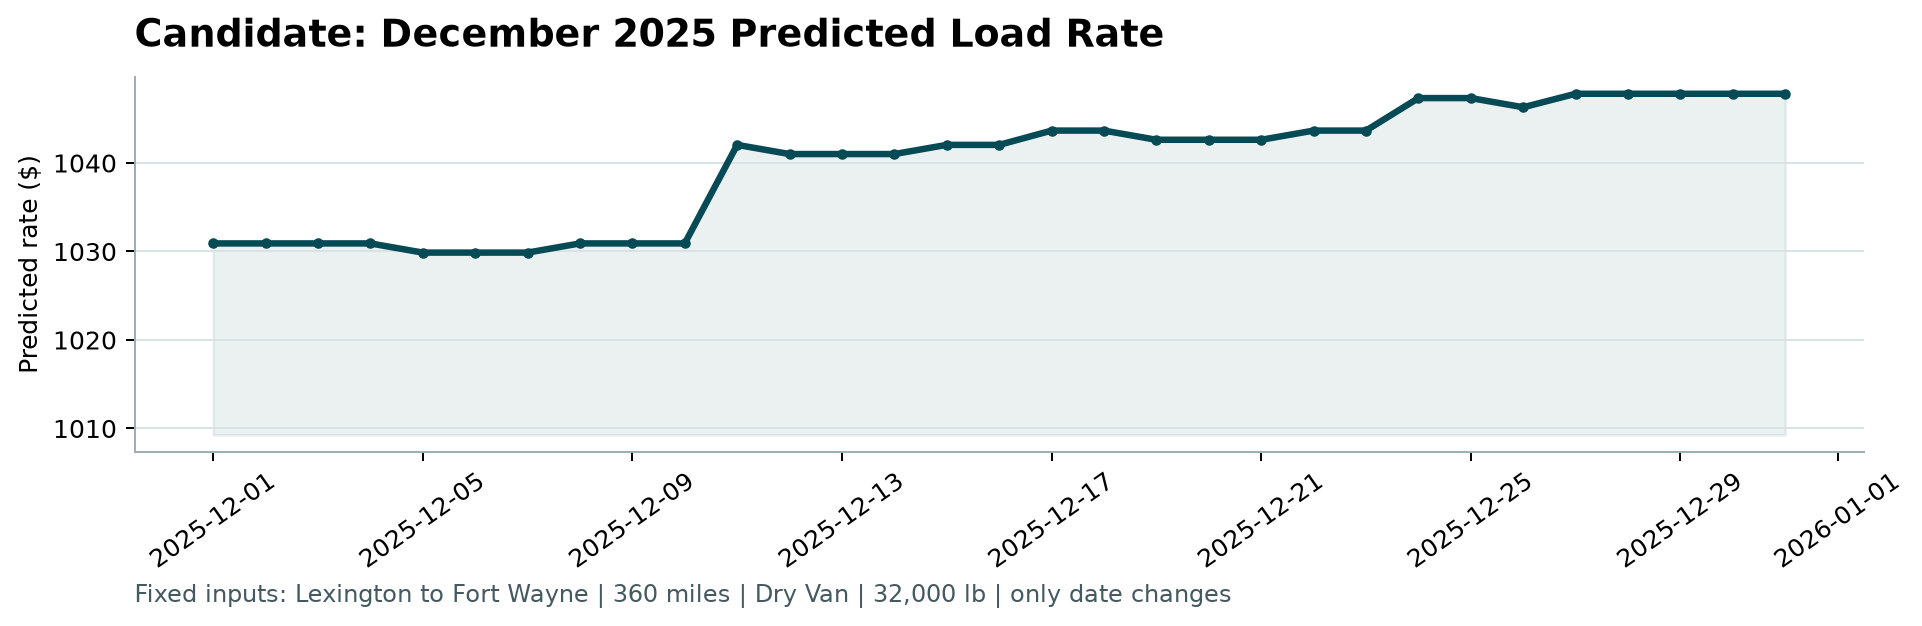

In [86]:
from IPython.display import Image, display

display(Image(filename="scorer_results/candidate_december.png"))

In [87]:
final_features = [
    "pickup",
    "delivery",
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "distance",
    "equipment",
    "weight",
    "market_index",
    "quote_signal",
    "month",
    "day",
    "day_of_week"
]

X_full = df[final_features].copy()
y_full = df["posted_rate"]

print("X shape:", X_full.shape)
print("y shape:", y_full.shape)
print("\nFeatures:")
print(X_full.columns.tolist())

X shape: (48000, 14)
y shape: (48000,)

Features:
['pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'market_index', 'quote_signal', 'month', 'day', 'day_of_week']


In [88]:
final_categorical_features = [
    "pickup",
    "delivery",
    "equipment"]
final_numerical_features = [
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "month",
    "day",
    "day_of_week"]
final_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))])
final_categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))])
final_preprocessor = ColumnTransformer(transformers=[
    ("num", final_numeric_transformer, final_numerical_features),
    ("cat", final_categorical_transformer, final_categorical_features)])
final_model = Pipeline(steps=[
    ("preprocessor", final_preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        min_samples_leaf=5,
        random_state=42))])

print("Final model created successfully.")

Final model created successfully.


In [89]:
final_model.fit(X_full, y_full)

print("Final model trained successfully on all 48,000 records!")

Final model trained successfully on all 48,000 records!


In [90]:
X_validation_final = validation_df[final_features]
final_validation_predictions = final_model.predict(X_validation_final)
print("Total predictions:", len(final_validation_predictions))
print("Minimum:", final_validation_predictions.min())
print("Maximum:", final_validation_predictions.max())
print("Average:", final_validation_predictions.mean())

Total predictions: 12000
Minimum: 249.01894134354447
Maximum: 6905.0832386860775
Average: 2388.6580535517774


In [91]:
print("NaN:", np.isnan(final_validation_predictions).sum())
print("Inf:", np.isinf(final_validation_predictions).sum())
print("<= 0:", (final_validation_predictions <= 0).sum())
final_predictions = pd.DataFrame({
    "load_id": validation_df["load_id"],
    "predicted_rate": final_validation_predictions})
final_predictions.to_csv("validation_predictions.csv", index=False)
print("\nSaved successfully!")
print(final_predictions.shape)
print(final_predictions.head())

NaN: 0
Inf: 0
<= 0: 0

Saved successfully!
(12000, 2)
     load_id  predicted_rate
0  TE-000001      864.568535
1  TE-000002     5050.660741
2  TE-000003     5354.494474
3  TE-000004     4090.072836
4  TE-000005     1843.563129


In [92]:
X_december_final = december_df[final_features]

final_december_predictions = final_model.predict(X_december_final)

december_df["predicted_rate"] = final_december_predictions

print(december_df[["date", "predicted_rate"]])

print("\nNaN:", np.isnan(final_december_predictions).sum())
print("Inf:", np.isinf(final_december_predictions).sum())
print("<= 0:", (final_december_predictions <= 0).sum())
print("Average:", final_december_predictions.mean())

         date  predicted_rate
0  2025-12-01      850.399692
1  2025-12-02      850.399692
2  2025-12-03      851.520024
3  2025-12-04      851.520024
4  2025-12-05      849.617909
5  2025-12-06      849.617909
6  2025-12-07      849.617909
7  2025-12-08      850.399692
8  2025-12-09      850.399692
9  2025-12-10      851.520024
10 2025-12-11      849.215120
11 2025-12-12      847.313004
12 2025-12-13      847.313004
13 2025-12-14      849.448874
14 2025-12-15      852.398325
15 2025-12-16      852.398325
16 2025-12-17      853.518658
17 2025-12-18      853.518658
18 2025-12-19      851.616542
19 2025-12-20      851.616542
20 2025-12-21      851.616542
21 2025-12-22      852.398325
22 2025-12-23      852.398325
23 2025-12-24      853.518658
24 2025-12-25      853.518658
25 2025-12-26      851.616542
26 2025-12-27      851.616542
27 2025-12-28      851.616542
28 2025-12-29      852.398325
29 2025-12-30      852.398325
30 2025-12-31      853.518658

NaN: 0
Inf: 0
<= 0: 0
Average: 851.2898

In [94]:
december_output = december_df[
    ["pickup", "delivery", "distance", "equipment",
     "weight", "date", "predicted_rate"]
].copy()

december_output["date"] = pd.to_datetime(
    december_output["date"]
).dt.strftime("%Y-%m-%d")

december_output.to_csv("december-chart-inputs.csv", index=False)

print("Final December file saved!")
print("Shape:", december_output.shape)
print("Missing predictions:", december_output["predicted_rate"].isna().sum())

Final December file saved!
Shape: (31, 7)
Missing predictions: 0


In [95]:
!python score.py --predictions validation_predictions.csv --december-predictions december-chart-inputs.csv

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results\candidate_december.png
Final validation metrics are calculated by Spotter after submission.


In [97]:
import os
print(os.listdir())

['december-chart-inputs.csv', 'score.py', 'scorer_results', 'train-test.csv', 'validation-predictions-template.csv', 'validation.csv', 'validation_predictions.csv']
